In [ ]:
%pip install qiskit qiskit_aer rustworkx matplotlib numpy pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7a34fc8f4f45dcf6d8d125b72252375f5bd553d606e121e8ad44e8be1c262c39
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator


# The MaxCut problem

Given a graph $G = (V,E)$, partition the vertices into two sets $S$ and $\bar{S}$
to maximize the number of edges crossing the partition. Encode each vertex $i$
with a bit $x_i \in \{0,1\}$, where $x_i$ indicates which side it is on. The
classical cost function is

$$
C(x)
=
\sum_{(i,j)\in E} x_i(1-x_j) + x_j(1-x_i)
=
\sum_{(i,j)\in E} \left[x_i + x_j - 2x_i x_j\right].
$$

This counts $1$ per edge that is cut (endpoints on different sides) and $0$
per edge that is not.

In quantum form, replace bits by qubits. Using Pauli $Z$, the cut indicator for
edge $(i, j)$ becomes

$$C_{ij} = \frac{1 - Z_i Z_j}{2}.$$

So the cost Hamiltonian is

$$H_C = \sum_{(i,j) \in E} \frac{1 - Z_i Z_j}{2}.$$

The goal is to prepare a quantum state whose measurement gives bitstrings $x$
with large $C(x)$.

Instead of the uniform initial state $H^{\otimes n}|0\rangle$, we prepare a **biased** initial state using the Walsh Series Loader (WSL), so that measuring it already favors good cuts.

This notebook implements and verifies the WSL construction on a single small example -- the 5-cycle $C_5$ -- where we can fully simulate the statevector and check every step against the exact classical answer.

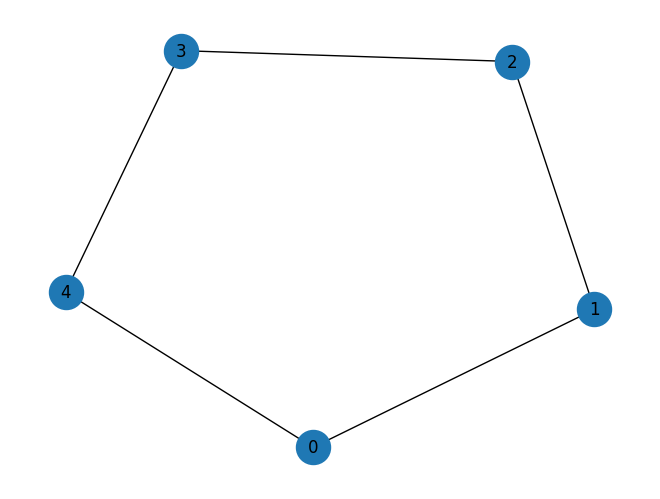

In [ ]:
# ---------------------------------------------------------------------------
# Graph: C5 cycle, vertices 0-1-2-3-4-0 (an odd cycle -- can't be perfectly
# bipartitioned, so MaxCut < |E| always. This makes it a good minimal test
# case: uniform sampling won't trivially find the optimum.)
# ---------------------------------------------------------------------------
n_vertices = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n_vertices, 1))
edge_list = [
    (0, 1, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
    (1, 2, 1.0),
    (4, 0, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)


# Appendix A.1 recap: loading a real-valued function

The Walsh Series Loader (Appendix A.1) loads a real-valued function
$f:[0,1]\to\mathbb R$ into an $n$-qubit state by discretizing $[0,1]$ into
$N=2^n$ points $\mathcal X_n=\{0,\tfrac1N,\dots,\tfrac{N-1}{N}\}$ and expanding
$f$ in the Walsh basis.

**For Max-Cut**, each of the $N=2^n$ discretization points corresponds exactly
to one of the $2^n$ bitstrings $x=x_0x_1\cdots x_{n-1}\in\{0,1\}^n$, i.e. one
cut. Qubit $i$ of the register *is* bit $x_i$ -- no separate encoding step is
needed.

We use the bias function

$$
f(x) = 1 + \lambda\Bigl(c(x)-\tfrac12\Bigr), \qquad c(x)=\frac{C(x)}{|E|}\in[0,1],\quad 0\le\lambda<2,
$$

which stays an **exact, sparse** Walsh series (one constant term $a_0=1$, plus
one term $a_{\{i,j\}}=-\lambda/(2|E|)$ per edge):

$$
f(x) = 1 - \frac{\lambda}{2|E|}\sum_{(i,j)\in E} (-1)^{x_i+x_j}.
$$


In [ ]:
# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
edges = [(i, j) for (i, j, _) in edge_list]   # plain (i,j) pairs, drop weights
m = len(edges)                                 # number of edges = |E|

epsilon0 = 0.6   # interference-scheme angle: controls both the success
                 # probability of postselection and (together with lambda)
                 # how sharply the state is biased toward good cuts.
lamda = 1.8      # bias strength, 0 <= lamda < 2 (see f(x) formula above).

a0 = 1.0                    # Walsh coefficient of the constant (empty-support) term
a_edge = -lamda / (2 * m)   # Walsh coefficient shared by every edge term (unweighted graph)

print(f"m = {m} edges, a0 = {a0}, a_edge = {a_edge:.4f}, epsilon0 = {epsilon0}")


m = 5 edges, a0 = 1.0, a_edge = -0.1800, epsilon0 = 0.6


### The controlled Walsh-term gate

Implements a controlled $\exp(i\,\text{coeff}\cdot Z_{q_1}Z_{q_2}\cdots)$ for an arbitrary qubit subset (`support`), controlled by the ancilla:

- **empty support** (the constant term): just a controlled phase on the ancilla itself (`qc.p`) -- there's no register qubit to condition on.
- **one qubit**: a single controlled-$R_Z$.
- **two or more qubits** (every MaxCut edge term has exactly two): a CNOT staircase computes the parity of the support onto the last qubit, a controlled-$R_Z$ applies the rotation, then the staircase is undone.

In [ ]:
def controlled_Walsh(qc, control, position_qubits, support, coeff):
    """Implements controlled exp(i * coeff * Z_{support[0]} Z_{support[1]} ...).

    support: list of indices into position_qubits (NOT qubit objects).
    coeff:   the rotation angle for this term, already scaled by epsilon0.
    """
    if len(support) == 0:
        # Constant term: unconditional phase e^{i*coeff} within the |1>_control branch only.
        qc.p(coeff, control)
        return

    if len(support) == 1:
        # Single-qubit Walsh term: one controlled rotation, no parity computation needed.
        qc.crz(-2 * coeff, control, position_qubits[support[0]])
        return

    # Two-or-more-qubit term (every MaxCut edge term is exactly this, with |support|=2):
    target = position_qubits[support[-1]]

    # Compute parity of the support onto `target` via a CNOT staircase.
    for q in support[:-1]:
        qc.cx(position_qubits[q], target)

    # Rotate by an amount controlled by the ancilla and by the computed parity.
    qc.crz(-2 * coeff, control, target)

    # Uncompute the parity so `target` returns to its original value.
    for q in reversed(support[:-1]):
        qc.cx(position_qubits[q], target)


### Build the circuit

`walsh_terms` must contain the constant term plus **one two-qubit term per edge** (`support=[i,j]`, the edge's own two endpoint qubits) -- not the same full-register support repeated `m` times, which doesn't encode the cost function at all. `epsilon0` is now actually multiplied into every coefficient, matching the theory ($\widehat U_{f,\epsilon_0}=e^{-i\widehat f\epsilon_0}$) -- it was computed but silently unused before.

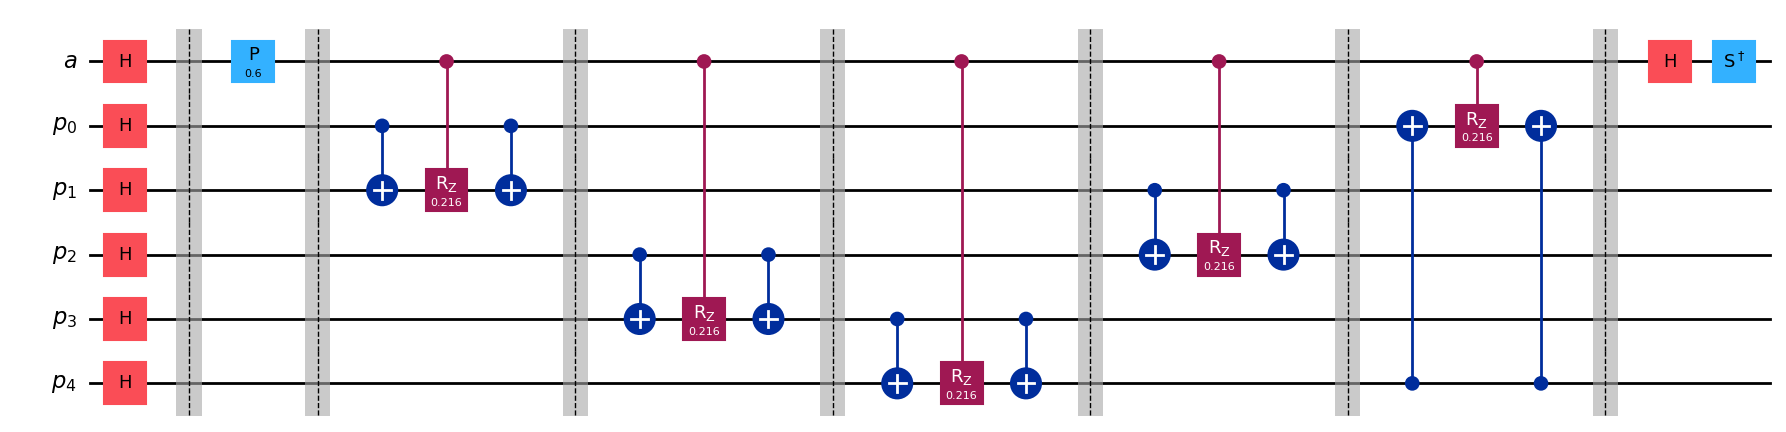

In [ ]:
ancilla_qubit = QuantumRegister(1, name="a")
position_qubits = QuantumRegister(m, name="p")

qc = QuantumCircuit(ancilla_qubit, position_qubits)

# Step 1: uniform superposition on both the ancilla and the register.
qc.h(ancilla_qubit)
qc.h(position_qubits)
qc.barrier()

# Step 2: one Walsh term per piece of f -- the constant term, then one
# two-qubit term per graph edge. Every coefficient is scaled by epsilon0 here.
walsh_terms = [([], a0 * epsilon0)] + [(list(e), a_edge * epsilon0) for e in edges]

for support, coeff in walsh_terms:
    controlled_Walsh(qc, ancilla_qubit, position_qubits, support, coeff)
    qc.barrier()

# Step 3: ancilla interference (H then Sdg = diag(1,-i)) -- turns the relative
# phase e^{i f(x) epsilon0} between the ancilla branches into an amplitude
# difference. Postselecting on ancilla=1 (done later) is what actually
# produces the bias -- see the README discussion for why the diagonal phase
# alone can never do this on its own.
qc.h(ancilla_qubit)
qc.sdg(ancilla_qubit)

qc.draw("mpl", fold=-1)


### Simulate on Aer and pull out the exact statevector

In [ ]:
qc_sim = qc.copy()
qc_sim.save_statevector()

simulator = AerSimulator(method="statevector")
tqc = transpile(qc_sim, simulator)
result = simulator.run(tqc).result()

full_state = np.asarray(result.get_statevector(tqc))

print("Number of qubits:", qc.num_qubits)
print("Statevector dimension:", len(full_state))


Number of qubits: 6
Statevector dimension: 64


### Reconstruct $f(x)\cdot\epsilon_0$ from the statevector, and verify it against the exact classical formula

Qubit 0 is the ancilla (added first, so it's the least-significant bit of the statevector index): `idx = (x << 1) | ancilla_bit`. Inverting the final $H$,$S^\dagger$ mixing recovers the pre-mixing relative phase $e^{if(x)\epsilon_0}$ between the two ancilla branches; its angle is exactly $f(x)\epsilon_0$.

In [ ]:
def reconstruct_f_from_statevector(full_state, n):
    """Inverts the ancilla H+Sdg mixing to recover f(x)*epsilon0 for each x."""
    N = 2**n
    f_vals = np.zeros(N)
    labels = []

    for x in range(N):
        idx0 = (x << 1) | 0   # ancilla = 0
        idx1 = (x << 1) | 1   # ancilla = 1

        A0 = full_state[idx0]
        A1 = full_state[idx1]

        Ux = (A0 - 1j * A1) / (A0 + 1j * A1)
        f_vals[x] = np.angle(Ux)

        labels.append(format(x, f"0{n}b")[::-1])  # bitstring in p[0] p[1] ... order

    return labels, f_vals


def cut_value(xb, edges):
    return sum(1 for (i, j) in edges if xb[i] != xb[j])


labels, f_quantum = reconstruct_f_from_statevector(full_state, m)

# --- Verification: compare against the exact classical f(x) ---
f_classical = np.zeros(2**m)
for x in range(2**m):
    xb = [(x >> i) & 1 for i in range(m)]
    c = cut_value(xb, edges)
    f_classical[x] = (1 + lamda * (c / m - 0.5)) * epsilon0

max_error = np.max(np.abs(f_quantum - f_classical))
print(f"Max |reconstructed - classical| over all {2**m} bitstrings: {max_error:.2e}")
print("(should be ~1e-15, i.e. exact up to floating point -- confirms the circuit is correct)")


Max |reconstructed - classical| over all 32 bitstrings: 3.33e-16
(should be ~1e-15, i.e. exact up to floating point -- confirms the circuit is correct)


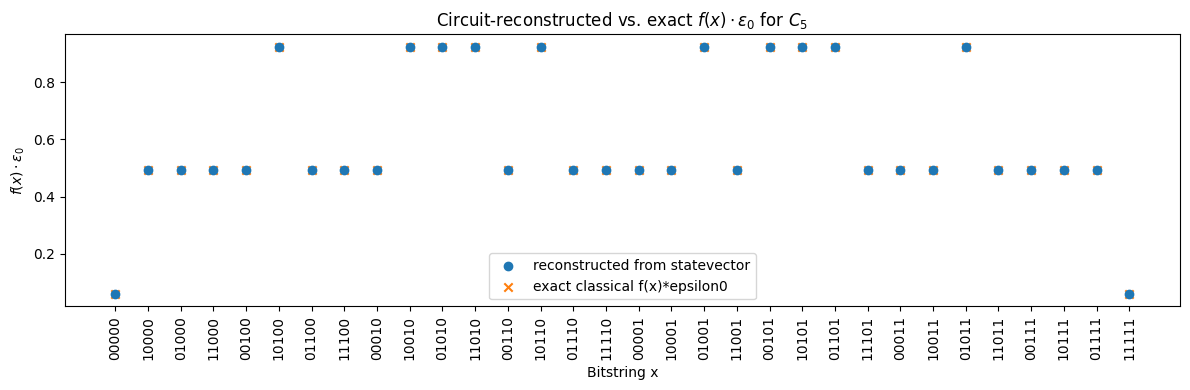

In [ ]:
plt.figure(figsize=(12, 4))
plt.scatter(labels, f_quantum, label="reconstructed from statevector", zorder=3)
plt.scatter(labels, f_classical, marker="x", label="exact classical f(x)*epsilon0", zorder=2)
plt.xlabel("Bitstring x")
plt.ylabel(r"$f(x)\cdot\epsilon_0$")
plt.title(r"Circuit-reconstructed vs. exact $f(x)\cdot\epsilon_0$ for $C_5$")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


## Measuring the biased state

Everything above confirms the *phases* are correct. Now build the same circuit with measurements, run it on the simulator, postselect on the ancilla measuring $1$, and check that the resulting distribution over cuts is actually biased toward high-cut bitstrings compared to uniform sampling.

In [ ]:
def build_wsl_circuit_with_measurement(m, walsh_terms):
    ancilla = QuantumRegister(1, name="a")
    position = QuantumRegister(m, name="p")
    meas = ClassicalRegister(m + 1, name="meas")

    qc = QuantumCircuit(ancilla, position, meas)
    a = ancilla[0]

    qc.h(a)
    qc.h(position)
    qc.barrier()

    for support, coeff in walsh_terms:
        controlled_Walsh(qc, a, position, support, coeff)
        qc.barrier()

    qc.h(a)
    qc.sdg(a)

    qc.measure(a, meas[0])
    for i in range(m):
        qc.measure(position[i], meas[i + 1])

    return qc


qc_measure = build_wsl_circuit_with_measurement(m, walsh_terms)

sim = AerSimulator()
tqc_measure = transpile(qc_measure, sim)
shots = 20000
counts = sim.run(tqc_measure, shots=shots).result().get_counts()


In [ ]:
def postselect_ancilla_one(counts, m):
    """counts keys look like "p4p3p2p1p0 a" (Qiskit prints classical bits
    right-to-left by register-declaration order); meas[0] is the ancilla,
    so it's the RIGHTMOST character."""
    post_counts = {}
    success_shots = 0
    total_shots = sum(counts.values())

    for key, count in counts.items():
        key = key.replace(" ", "")
        ancilla_bit = key[-1]
        position_bits = key[:-1][::-1]  # reverse p[m-1]...p[0] -> p[0]...p[m-1]

        if ancilla_bit == "1":
            success_shots += count
            post_counts[position_bits] = post_counts.get(position_bits, 0) + count

    return post_counts, success_shots, total_shots


post_counts, success_shots, total_shots = postselect_ancilla_one(counts, m)

print("Total shots:", total_shots)
print("Postselection success shots:", success_shots)
print("Postselection success probability:", success_shots / total_shots)


Total shots: 20000
Postselection success shots: 2026
Postselection success probability: 0.1013


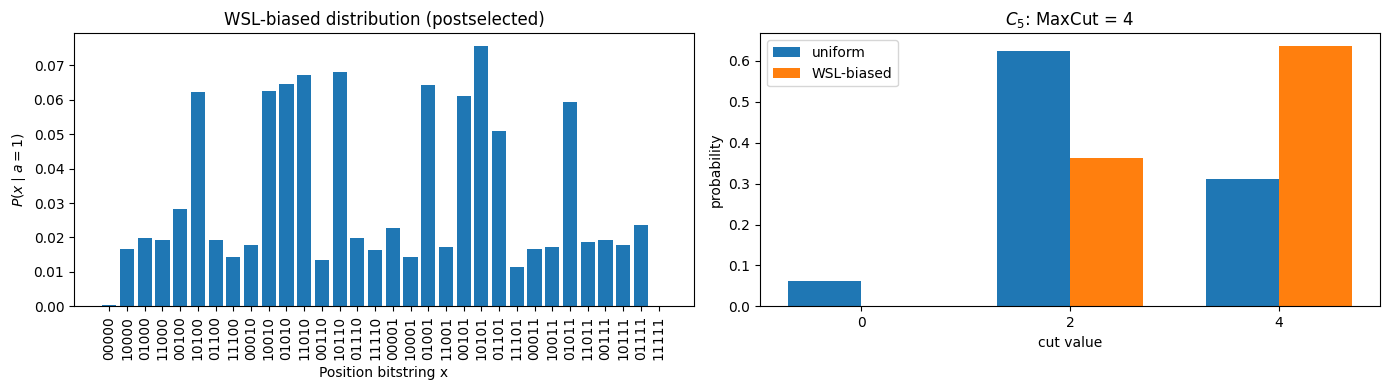

In [ ]:
labels_all = ["".join(str((x >> i) & 1) for i in range(m)) for x in range(2**m)]

post_probs = np.array([post_counts.get(lbl, 0) / success_shots for lbl in labels_all])
cut_values = np.array([cut_value([int(b) for b in lbl], edges) for lbl in labels_all])

uniform_probs = np.full(2**m, 1 / 2**m)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(labels_all, post_probs)
axes[0].set_xlabel("Position bitstring x")
axes[0].set_ylabel(r"$P(x \mid a=1)$")
axes[0].set_title("WSL-biased distribution (postselected)")
axes[0].tick_params(axis="x", rotation=90)

# group by cut value for a cleaner comparison against uniform
from collections import defaultdict
biased_by_cut, uniform_by_cut = defaultdict(float), defaultdict(float)
for p_bias, p_unif, c in zip(post_probs, uniform_probs, cut_values):
    biased_by_cut[c] += p_bias
    uniform_by_cut[c] += p_unif

cuts_sorted = sorted(biased_by_cut)
width = 0.35
x_pos = np.arange(len(cuts_sorted))
axes[1].bar(x_pos - width/2, [uniform_by_cut[c] for c in cuts_sorted], width, label="uniform")
axes[1].bar(x_pos + width/2, [biased_by_cut[c] for c in cuts_sorted], width, label="WSL-biased")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(cuts_sorted)
axes[1].set_xlabel("cut value")
axes[1].set_ylabel("probability")
axes[1].set_title(f"$C_5$: MaxCut = {max(cuts_sorted)}")
axes[1].legend()

plt.tight_layout()
plt.show()
